<a href="https://colab.research.google.com/github/eevvvaa/Deep_Generative_Model-HW/blob/week3/%E4%BD%BF%E7%94%A8_Seq2Seq_VAE%E7%94%9F%E6%88%90%E3%80%8C%E6%9C%AA%E4%BE%86%E5%AD%B8%E7%BF%92%E8%A1%8C%E7%82%BA%E5%BA%8F%E5%88%97%E3%80%8D%E6%95%B8%E6%93%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu
OULAD files not found - creating synthetic dataset (structure matches).


Preprocessing students: 100%|██████████| 1000/1000 [00:04<00:00, 225.56it/s]


Weekly data rows: 13719
Students: 1000
Created 8719 sequences.
Train seq: 6096, Val seq: 1309, Test seq: 1314

--- Training Seq2Seq LSTM ---
LSTM Epoch 2/12 - TrainLoss: 0.9011, ValMSE: 0.8866
LSTM Epoch 4/12 - TrainLoss: 0.8517, ValMSE: 0.8591
LSTM Epoch 6/12 - TrainLoss: 0.8374, ValMSE: 0.8440
LSTM Epoch 8/12 - TrainLoss: 0.8263, ValMSE: 0.8320
LSTM Epoch 10/12 - TrainLoss: 0.8176, ValMSE: 0.8240
LSTM Epoch 12/12 - TrainLoss: 0.8101, ValMSE: 0.8177


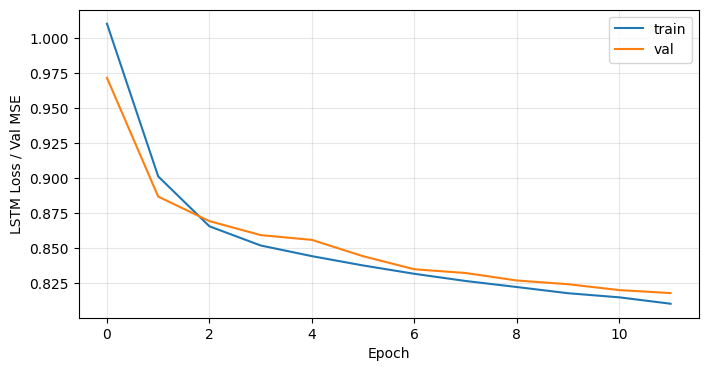

LSTM Test MSE (per value): 0.765016

--- Training Seq2Seq VAE ---
VAE Epoch 2/12 - TrainLoss: 1.0401 (Recon: 1.0316, KLD: 0.1697) ValLoss: 1.0477
VAE Epoch 4/12 - TrainLoss: 1.0191 (Recon: 0.9918, KLD: 0.5459) ValLoss: 1.0313
VAE Epoch 6/12 - TrainLoss: 1.0019 (Recon: 0.9667, KLD: 0.7038) ValLoss: 1.0174
VAE Epoch 8/12 - TrainLoss: 0.9667 (Recon: 0.9113, KLD: 1.1087) ValLoss: 0.9651
VAE Epoch 10/12 - TrainLoss: 0.9431 (Recon: 0.8813, KLD: 1.2348) ValLoss: 0.9606
VAE Epoch 12/12 - TrainLoss: 0.9450 (Recon: 0.8825, KLD: 1.2499) ValLoss: 0.9509


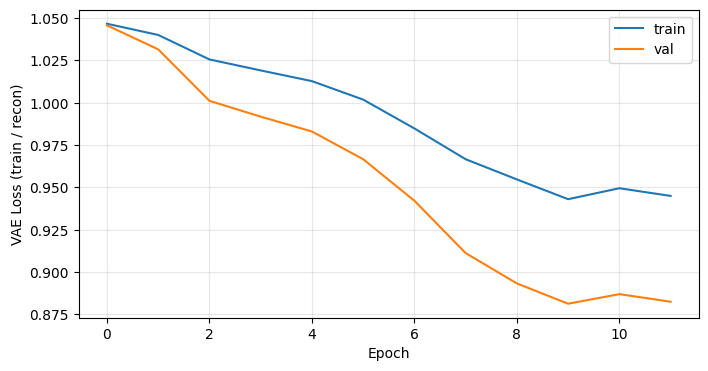

Top-5 Regressed (VAE best >> LSTM) ===
idx    LSTM_MSE   VAE_best_MSE   Δ(LSTM-VAE)   y_true   y_LSTM   y_VAE_best   Diversity_std
--------------------------------------------------------------------------------
 39       5.28           2.37           2.91   [ 3.1539605  -0.22617956]   [-0.09117807 -0.07937731]   [ 0.98086536 -0.12760425]     0.278755
 19       5.26           2.35           2.91   [-0.18589814  3.0026128 ]   [ 0.99510205 -0.01858179]   [0.5520388 0.9629353]     0.286920
 86       5.36           2.70           2.66   [-0.83550745  2.601326  ]   [ 1.036081   -0.08684988]   [0.47026265 0.6782172 ]     0.261817
307       4.31           2.06           2.25   [ 2.8818767 -1.0283664]   [0.14385352 0.02998702]   [ 1.0134151  -0.23952898]     0.244824
516       5.17           3.05           2.13   [-0.5507417  2.9689543]   [ 0.1145847  -0.17748603]   [0.37048903 0.6793635 ]     0.272869

Improvement bucket (Δ = LSTM MSE - VAE best MSE) ==
Bucket              Count    Ratio
----

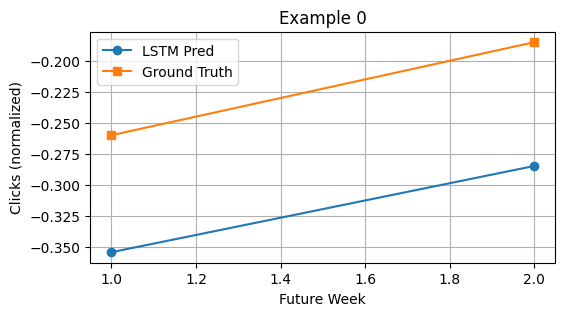

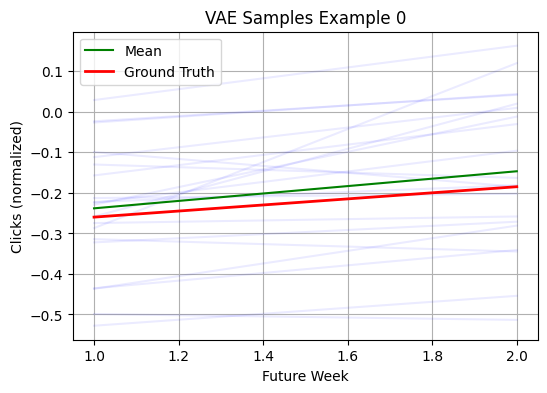


Example 2 - LSTM vs VAE samples


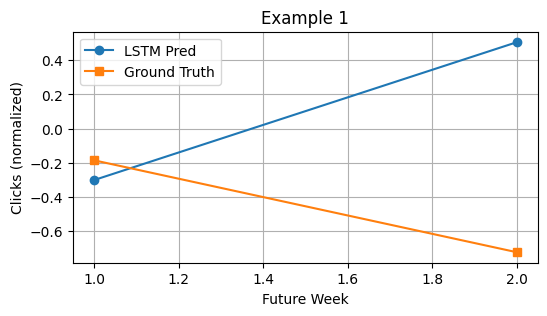

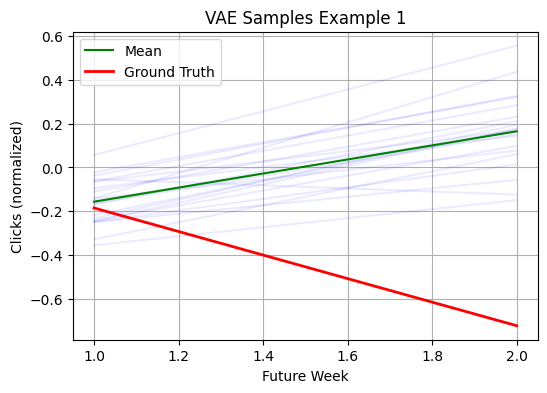


Example 3 - LSTM vs VAE samples


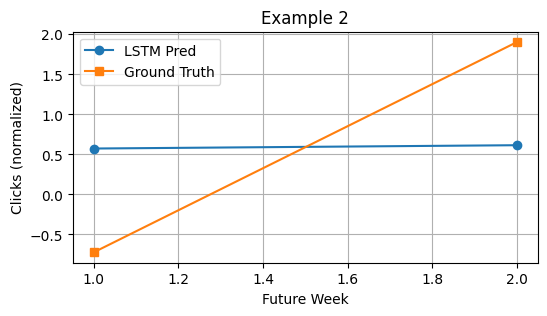

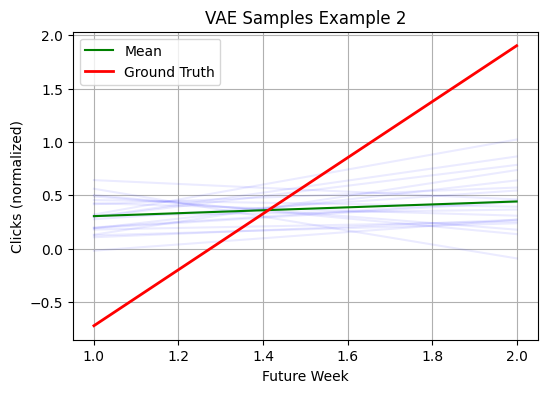


Models saved: seq2seq_lstm_oulad.pth, seq2seq_vae_oulad.pth

Done. Summary:
LSTM MSE: 0.765016
VAE Best-of-N MSE: 0.477463, Diversity: 0.188223, Coverage: 0.4559


In [2]:
# Seq2Seq LSTM vs Seq2Seq VAE - 完整 Colab/Local 可執行版本
# 符合作業 HW3 要求：同一程式檔包含
# - 資料讀取（若有 OULAD 三檔則讀取，否則自動產生模擬資料）
# - 特徵處理：clicks, submit_cnt/has_submit, avg_score_sofar, clicks_diff1
# - 以 student_id 切分 train/val/test（避免資料洩漏）
# - Seq2Seq LSTM（單一路徑預測未來 2 週） + Seq2Seq VAE（生成多樣化未來）
# - 訓練設定：batch_size=128, Adam lr=1e-3, seed=42
# - 評估指標：MSE (LSTM), Best-of-N MSE (VAE), Diversity, Coverage
# - 可視化函數
# 直接放到 Colab 執行即可（若要使用真實 OULAD ，上傳 studentInfo.csv/studentVle.csv/studentAssessment.csv）

import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------------------
# 固定隨機種子
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------
# 設備
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------------------
# 資料處理（支援讀取 OULAD 或自動產生模擬資料）
# ---------------------------
class DataHandler:
    def __init__(self, data_dir=None, min_weeks_needed=12):
        self.data_dir = data_dir
        self.min_weeks_needed = min_weeks_needed
        self.student_scalers = {}  # per-student scaler for feature normalization

    def load_oulad_or_synthetic(self):
        """嘗試讀取 OULAD 三檔，若不存在則回傳模擬資料"""
        if self.data_dir and all(os.path.exists(os.path.join(self.data_dir, fn)) for fn in
                                 ["studentInfo.csv", "studentVle.csv", "studentAssessment.csv"]):
            print("Loading OULAD files from", self.data_dir)
            si = pd.read_csv(os.path.join(self.data_dir, "studentInfo.csv"))
            sv = pd.read_csv(os.path.join(self.data_dir, "studentVle.csv"))
            sa = pd.read_csv(os.path.join(self.data_dir, "studentAssessment.csv"))
            return si, sv, sa
        else:
            print("OULAD files not found - creating synthetic dataset (structure matches).")
            return self.create_synthetic_data()

    def create_synthetic_data(self, n_students=1000, n_weeks=15):
        """產生模擬資料"""
        np.random.seed(SEED)
        student_info = pd.DataFrame({
            "id_student": np.arange(1, n_students + 1),
            "code_module": np.random.choice(["AAA", "BBB", "CCC"], size=n_students),
            "code_presentation": np.random.choice(["2013B", "2014J", "2014B"], size=n_students)
        })
        student_vle_rows = []
        for sid in range(1, n_students + 1):
            start_week = np.random.randint(1, 4)
            end_week = start_week + np.random.randint(self.min_weeks_needed, n_weeks + 1)
            end_week = min(end_week, n_weeks)
            student_type = np.random.choice(['active', 'average', 'inactive'], p=[0.3, 0.5, 0.2])
            if student_type == 'active':
                base = np.random.poisson(25)
                trend = np.random.choice([0.15, 0.25, 0.35])
                noise = 2.0
            elif student_type == 'average':
                base = np.random.poisson(15)
                trend = np.random.choice([-0.05, 0.0, 0.05])
                noise = 3.0
            else:
                base = np.random.poisson(8)
                trend = np.random.choice([-0.2, -0.1])
                noise = 2.0
            for w in range(start_week, end_week + 1):
                clicks = max(0, base + trend * w + np.random.normal(0, noise))
                if w in [5, 10, 14]:
                    clicks *= 1.5
                student_vle_rows.append({"id_student": sid, "date": w, "sum_click": clicks})
        student_vle = pd.DataFrame(student_vle_rows)

        student_assessment_rows = []
        for sid in range(1, n_students + 1):
            n_assess = np.random.randint(3, 7)
            for _ in range(n_assess):
                week = np.random.randint(2, n_weeks - 1)
                if sid % 3 == 0:
                    score = np.random.normal(85, 8)
                elif sid % 3 == 1:
                    score = np.random.normal(70, 12)
                else:
                    score = np.random.normal(55, 15)
                score = float(max(0, min(100, score)))
                student_assessment_rows.append({"id_student": sid, "date": int(week), "score": score})
        student_assessment = pd.DataFrame(student_assessment_rows)

        return student_info, student_vle, student_assessment

    def preprocess_weekly(self, student_info, student_vle, student_assessment, target_seq_len=8, future_len=2):
        """以學生為單位產生每周序列"""
        records = []
        for sid in tqdm(student_info['id_student'].unique(), desc="Preprocessing students"):
            s_clicks = student_vle[student_vle['id_student'] == sid].copy()
            if s_clicks.empty:
                continue
            min_w, max_w = int(s_clicks['date'].min()), int(s_clicks['date'].max())
            if (max_w - min_w + 1) < self.min_weeks_needed:
                continue
            weeks = np.arange(min_w, max_w + 1)
            dfw = pd.DataFrame({"week": weeks})
            df_clicks = s_clicks.rename(columns={"date": "week", "sum_click": "clicks"})[['week', 'clicks']]
            df = dfw.merge(df_clicks, on='week', how='left').fillna(0)
            s_assess = student_assessment[student_assessment['id_student'] == sid]
            df['submit_cnt'] = 0
            df['avg_score_sofar'] = 0.0
            cumulative = 0.0
            cnt = 0
            for _, row in s_assess.iterrows():
                w = int(row['date'])
                if w in df['week'].values:
                    idx = df.index[df['week'] == w][0]
                    df.at[idx, 'submit_cnt'] = 1
                    cumulative += float(row['score'])
                    cnt += 1
                    df.at[idx, 'avg_score_sofar'] = cumulative / cnt
            df['clicks_diff1'] = df['clicks'].diff().fillna(0)
            df['student_id'] = sid
            records.append(df)
        if not records:
            raise ValueError("No students with sufficient weeks after preprocessing.")
        weekly = pd.concat(records, ignore_index=True)
        return weekly

    def create_sequences(self, weekly_df, seq_length=4, pred_length=2):  # 改為4週輸入
        """對每位學生用滑動窗口建立 (input_seq, output_seq)"""
        seqs = []
        features = ['clicks', 'submit_cnt', 'avg_score_sofar', 'clicks_diff1']
        for sid in weekly_df['student_id'].unique():
            sd = weekly_df[weekly_df['student_id'] == sid].sort_values('week').reset_index(drop=True)
            if len(sd) < seq_length + pred_length:
                continue
            data = sd[features].values.astype(np.float32)
            scaler = StandardScaler()
            try:
                data_scaled = scaler.fit_transform(data)
            except Exception:
                continue
            self.student_scalers[sid] = scaler
            n = len(sd)
            for i in range(0, n - seq_length - pred_length + 1):
                inp = data_scaled[i:i + seq_length]
                out = data_scaled[i + seq_length:i + seq_length + pred_length, 0]
                seqs.append({'input': inp.astype(np.float32), 'output': out.astype(np.float32), 'student_id': sid})
        print(f"Created {len(seqs)} sequences.")
        return seqs

# ---------------------------
# Dataset / DataLoader
# ---------------------------
class SequenceDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        s = self.sequences[idx]
        return torch.tensor(s['input'], dtype=torch.float32), torch.tensor(s['output'], dtype=torch.float32)

# ---------------------------
# Seq2Seq LSTM (單一路徑預測)
# ---------------------------
class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_dim=4, enc_hidden=64, dec_hidden=64, num_layers=1, pred_len=2):
        super().__init__()
        self.input_dim = input_dim
        self.enc_hidden = enc_hidden
        self.dec_hidden = dec_hidden
        self.num_layers = num_layers
        self.pred_len = pred_len

        self.encoder = nn.LSTM(input_dim, enc_hidden, num_layers=num_layers, batch_first=True, bidirectional=False)
        self.decoder_fc = nn.Sequential(
            nn.Linear(enc_hidden, dec_hidden),
            nn.ReLU(),
            nn.Linear(dec_hidden, pred_len)
        )

    def forward(self, x):
        _, (h_n, _) = self.encoder(x)
        h_last = h_n[-1]
        out = self.decoder_fc(h_last)
        return out

# ---------------------------
# Seq2Seq VAE
# ---------------------------
class Seq2SeqVAE(nn.Module):
    def __init__(self, input_dim=4, enc_hidden=64, latent_dim=16, dec_hidden=64, num_layers=1, pred_len=2, bidirectional=True):
        super().__init__()
        self.input_dim = input_dim
        self.enc_hidden = enc_hidden
        self.latent_dim = latent_dim
        self.dec_hidden = dec_hidden
        self.num_layers = num_layers
        self.pred_len = pred_len
        self.bidirectional = bidirectional

        self.encoder = nn.LSTM(input_dim, enc_hidden, num_layers=num_layers, batch_first=True, bidirectional=bidirectional)
        enc_output_dim = enc_hidden * (2 if bidirectional else 1)
        self.fc_mu = nn.Linear(enc_output_dim, latent_dim)
        self.fc_logvar = nn.Linear(enc_output_dim, latent_dim)
        self.decoder_lstm = nn.LSTM(latent_dim, dec_hidden, num_layers=1, batch_first=True)
        self.decoder_out = nn.Linear(dec_hidden, 1)

    def encode(self, x):
        _, (h_n, _) = self.encoder(x)
        if self.bidirectional:
            if self.num_layers >= 1:
                h_forward = h_n[-2]
                h_backward = h_n[-1]
                h = torch.cat([h_forward, h_backward], dim=1)
            else:
                h = h_n.view(h_n.size(1), -1)
        else:
            h = h_n[-1]
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, pred_len=None):
        if pred_len is None:
            pred_len = self.pred_len
        z_seq = z.unsqueeze(1).repeat(1, pred_len, 1)
        dec_out, _ = self.decoder_lstm(z_seq)
        out = self.decoder_out(dec_out).squeeze(-1)
        return out

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, self.pred_len)
        return recon, mu, logvar

# ---------------------------
# 損失與訓練/驗證函數
# ---------------------------
def kld_loss_from_mu_logvar(mu, logvar):
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    return torch.mean(kld)

def train_lstm_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    mse_criterion = nn.MSELoss()
    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = mse_criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    return total_loss / len(loader.dataset)

def eval_lstm(model, loader, device):
    model.eval()
    mse_criterion = nn.MSELoss(reduction='sum')
    total_loss = 0.0
    preds = []
    targets = []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device); y = y.to(device)
            pred = model(X)
            total_loss += mse_criterion(pred, y).item()
            preds.append(pred.cpu().numpy())
            targets.append(y.cpu().numpy())
    mse = total_loss / (len(loader.dataset) * loader.dataset[0][1].shape[0])
    preds = np.vstack(preds)
    targets = np.vstack(targets)
    return mse, preds, targets

def train_vae_epoch(model, loader, optimizer, device, beta=0.05):  # 調整beta值
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kld = 0.0
    mse_criterion = nn.MSELoss(reduction='mean')
    for X, y in loader:
        X = X.to(device); y = y.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(X)
        recon_loss = mse_criterion(recon, y)
        kld = kld_loss_from_mu_logvar(mu, logvar)
        loss = recon_loss + beta * kld
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        total_recon += recon_loss.item() * X.size(0)
        total_kld += kld.item() * X.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kld / n

def eval_vae(model, loader, device, num_samples=20):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            batch_preds = []
            for s in range(num_samples):
                recon, _, _ = model(X)
                batch_preds.append(recon.cpu().numpy())
            batch_preds = np.stack(batch_preds, axis=0)
            batch_preds = np.transpose(batch_preds, (1, 0, 2))
            all_preds.append(batch_preds)
            all_targets.append(y.numpy())
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    return all_preds, all_targets

# ---------------------------
# 評估指標（Best-of-N MSE、Diversity、Coverage）
# ---------------------------
def best_of_n_mse(predictions, targets, n=None):
    if n is None:
        n = predictions.shape[1]
    N = predictions.shape[0]
    mses = []
    for i in range(N):
        sample_mses = np.mean((predictions[i, :n, :] - targets[i]) ** 2, axis=1)
        mses.append(np.min(sample_mses))
    return float(np.mean(mses))

def diversity_metric(predictions):
    per_example_std = np.std(predictions, axis=1)
    return float(np.mean(per_example_std))

def coverage_metric_dynamic(predictions, targets, lstm_preds, lstm_targets):
    """使用LSTM MSE中位數作為Coverage閾值"""
    lstm_mses = np.mean((lstm_preds - lstm_targets) ** 2, axis=1)
    threshold = np.median(lstm_mses)

    N = predictions.shape[0]
    covered = 0
    for i in range(N):
        pred_min = np.min(predictions[i], axis=0)
        pred_max = np.max(predictions[i], axis=0)
        tgt = targets[i]
        if np.all((tgt >= pred_min - threshold) & (tgt <= pred_max + threshold)):
            covered += 1
    return covered / N, threshold

def calculate_improvement_distribution(lstm_preds, lstm_tgts, vae_preds, vae_tgts):
    """計算改善分佈"""
    improvements = []
    for i in range(len(lstm_preds)):
        lstm_mse = np.mean((lstm_preds[i] - lstm_tgts[i])**2)
        vae_best_mse = np.min(np.mean((vae_preds[i] - vae_tgts[i])**2, axis=1))
        improvements.append(lstm_mse - vae_best_mse)

    improvements = np.array(improvements)

    buckets = [
        'VAE<<劣(>1000)', 'VAE劣(200~1000)', 'VAE劣(50~200)', 'VAE劣(10~50)', 'VAE略劣(<10)',
        '*打平(±10)', 'VAE略勝(10~50)', 'VAE勝(50~200)', 'VAE大勝(200~1000)', 'VAE>>大勝(>1000)'
    ]

    ranges = [
        (-np.inf, -1000), (-1000, -200), (-200, -50), (-50, -10), (-10, 0),
        (-10, 10), (10, 50), (50, 200), (200, 1000), (1000, np.inf)
    ]

    counts = []
    for r_min, r_max in ranges:
        if r_min == -np.inf:
            count = np.sum(improvements <= r_max)
        elif r_max == np.inf:
            count = np.sum(improvements >= r_min)
        else:
            count = np.sum((improvements >= r_min) & (improvements < r_max))
        counts.append(count)

    total = len(improvements)
    ratios = [count/total for count in counts]

    return buckets, counts, ratios

# ---------------------------
# 可視化工具
# ---------------------------
def plot_training_curves(train_vals, val_vals, title="Loss"):
    plt.figure(figsize=(8,4))
    plt.plot(train_vals, label='train')
    plt.plot(val_vals, label='val')
    plt.xlabel('Epoch')
    plt.ylabel(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_example_predictions_lstm(preds, targets, idx=0):
    p = preds[idx]
    t = targets[idx]
    x = np.arange(1, len(p)+1)
    plt.figure(figsize=(6,3))
    plt.plot(x, p, '-o', label='LSTM Pred')
    plt.plot(x, t, '-s', label='Ground Truth')
    plt.xlabel('Future Week')
    plt.ylabel('Clicks (normalized)')
    plt.title(f"Example {idx}")
    plt.legend(); plt.grid(True); plt.show()

def plot_example_predictions_vae(predictions, targets, idx=0, plot_n=20):
    preds = predictions[idx][:plot_n]
    t = targets[idx]
    x = np.arange(1, preds.shape[1]+1)
    plt.figure(figsize=(6,4))
    for s in range(preds.shape[0]):
        plt.plot(x, preds[s], color='blue', alpha=0.08)
    plt.plot(x, np.mean(preds, axis=0), color='green', label='Mean')
    plt.plot(x, t, color='red', linewidth=2, label='Ground Truth')
    plt.xlabel('Future Week'); plt.ylabel('Clicks (normalized)')
    plt.title(f"VAE Samples Example {idx}")
    plt.legend(); plt.grid(True); plt.show()

def plot_vae_analysis_tables(lstm_preds, lstm_targets, vae_preds, vae_targets, vae_num_samples=20):
    """生成VAE分析表格"""
    # 計算Top-5改善案例
    improvements = []
    top5_data = []

    for i in range(len(lstm_preds)):
        lstm_mse = np.mean((lstm_preds[i] - lstm_targets[i])**2)
        vae_sample_mses = np.mean((vae_preds[i] - vae_targets[i])**2, axis=1)
        vae_best_mse = np.min(vae_sample_mses)
        vae_best_idx = np.argmin(vae_sample_mses)
        improvement = lstm_mse - vae_best_mse
        improvements.append(improvement)

        diversity_std = np.std(vae_preds[i], axis=0).mean()

        # 修正這裡：使用字典鍵來訪問數據
        if len(top5_data) < 5 or improvement > min([x['improvement'] for x in top5_data]):
            top5_data.append({
                'idx': i,
                'lstm_mse': lstm_mse,
                'vae_best_mse': vae_best_mse,
                'improvement': improvement,
                'y_true': vae_targets[i],
                'y_lstm': lstm_preds[i],
                'y_vae_best': vae_preds[i][vae_best_idx],
                'diversity_std': diversity_std
            })
            # 保持只保留前5名
            top5_data = sorted(top5_data, key=lambda x: x['improvement'], reverse=True)[:5]

    # 表格1: Top-5 Regressed (VAE best >> LSTM)
    print("="*80)
    print("Top-5 Regressed (VAE best >> LSTM) ===")
    print("="*80)
    print("idx    LSTM_MSE   VAE_best_MSE   Δ(LSTM-VAE)   y_true   y_LSTM   y_VAE_best   Diversity_std")
    print("-"*80)
    for i, data in enumerate(top5_data):
        print(f"{data['idx']:3}   {data['lstm_mse']:8.2f}   {data['vae_best_mse']:12.2f}   {data['improvement']:12.2f}   {data['y_true']}   {data['y_lstm']}   {data['y_vae_best']}   {data['diversity_std']:10.6f}")

    # 計算改善分佈
    buckets, counts, ratios = calculate_improvement_distribution(lstm_preds, lstm_targets, vae_preds, vae_targets)

    # 表格2: Improvement Bucket Distribution
    print("\n" + "="*60)
    print("Improvement bucket (Δ = LSTM MSE - VAE best MSE) ==")
    print("="*60)
    print("Bucket              Count    Ratio")
    print("-"*60)
    for bucket, count, ratio in zip(buckets, counts, ratios):
        print(f"{bucket:18} {count:6}   {ratio:.4f}")

    # 計算整體指標
    lstm_overall_mse = np.mean((lstm_preds - lstm_targets)**2)
    vae_best_overall_mse = best_of_n_mse(vae_preds, vae_targets, n=vae_num_samples)
    vae_diversity = diversity_metric(vae_preds)
    vae_coverage, coverage_threshold = coverage_metric_dynamic(vae_preds, vae_targets, lstm_preds, lstm_targets)

    # 表格3: 整體評估結果
    print("\n" + "="*50)
    print("評估結果（原始尺度）")
    print("="*50)
    print(f"LSTM    MSE（整體）    : {lstm_overall_mse:.4f}")
    print(f"VAE    Best-of-N MSE    : {vae_best_overall_mse:.4f} (N={vae_num_samples})")
    print(f"VAE    Diversity (std)    : {vae_diversity:.4f}")
    print(f"VAE    Coverage (比例)    : {vae_coverage:.4f}")
    print(f"（門檻 τ = LSTM 每序列 MSE 中位數 = {coverage_threshold:.4f}）")
    print("="*50)

# ---------------------------
# 主流程
# ---------------------------
def main_flow(data_dir=None,
              seq_len=4,  # 改為4週輸入
              pred_len=2,
              batch_size=128,
              lstm_hidden=64,
              vae_enc_hidden=64,
              vae_latent=16,
              epochs=12,
              beta=0.05,  # 調整beta值
              vae_num_samples=20):

    dh = DataHandler(data_dir=data_dir, min_weeks_needed=12)
    student_info, student_vle, student_assessment = dh.load_oulad_or_synthetic()

    weekly = dh.preprocess_weekly(student_info, student_vle, student_assessment)
    print("Weekly data rows:", len(weekly))
    print("Students:", weekly['student_id'].nunique())

    sequences = dh.create_sequences(weekly, seq_length=seq_len, pred_length=pred_len)
    if len(sequences) == 0:
        raise ValueError("No sequences created. Check data or parameters.")

    student_ids = sorted(list({s['student_id'] for s in sequences}))
    train_ids, temp_ids = train_test_split(student_ids, test_size=0.3, random_state=SEED)
    val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=SEED)

    train_seq = [s for s in sequences if s['student_id'] in train_ids]
    val_seq = [s for s in sequences if s['student_id'] in val_ids]
    test_seq = [s for s in sequences if s['student_id'] in test_ids]

    print(f"Train seq: {len(train_seq)}, Val seq: {len(val_seq)}, Test seq: {len(test_seq)}")

    train_loader = DataLoader(SequenceDataset(train_seq), batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(SequenceDataset(val_seq), batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader = DataLoader(SequenceDataset(test_seq), batch_size=batch_size, shuffle=False, drop_last=False)

    # ---------------------------
    # Train Seq2Seq LSTM
    # ---------------------------
    print("\n--- Training Seq2Seq LSTM ---")
    lstm_model = Seq2SeqLSTM(input_dim=4, enc_hidden=lstm_hidden, dec_hidden=lstm_hidden, num_layers=1, pred_len=pred_len).to(device)
    lstm_opt = optim.Adam(lstm_model.parameters(), lr=1e-3)
    lstm_train_losses = []
    lstm_val_losses = []

    for ep in range(epochs):
        train_loss = train_lstm_epoch(lstm_model, train_loader, lstm_opt, device)
        val_mse, _, _ = eval_lstm(lstm_model, val_loader, device)
        lstm_train_losses.append(train_loss)
        lstm_val_losses.append(val_mse)
        if (ep+1) % max(1, epochs//5) == 0:
            print(f"LSTM Epoch {ep+1}/{epochs} - TrainLoss: {train_loss:.4f}, ValMSE: {val_mse:.4f}")

    plot_training_curves(lstm_train_losses, lstm_val_losses, title="LSTM Loss / Val MSE")

    lstm_test_mse, lstm_preds, lstm_targets = eval_lstm(lstm_model, test_loader, device)
    print(f"LSTM Test MSE (per value): {lstm_test_mse:.6f}")

    # ---------------------------
    # Train Seq2Seq VAE
    # ---------------------------
    print("\n--- Training Seq2Seq VAE ---")
    vae_model = Seq2SeqVAE(input_dim=4, enc_hidden=vae_enc_hidden, latent_dim=vae_latent, dec_hidden=vae_enc_hidden, num_layers=1, pred_len=pred_len).to(device)
    vae_opt = optim.Adam(vae_model.parameters(), lr=1e-3)
    vae_train_losses = []
    vae_val_losses = []
    vae_recon_losses = []
    vae_kld_losses = []

    for ep in range(epochs):
        t_loss, t_recon, t_kld = train_vae_epoch(vae_model, train_loader, vae_opt, device, beta=beta)
        vae_model.eval()
        val_recon = 0.0
        val_kld = 0.0
        n_val = 0
        with torch.no_grad():
            for Xv, yv in val_loader:
                Xv = Xv.to(device); yv = yv.to(device)
                recon, mu, logvar = vae_model(Xv)
                val_recon += nn.MSELoss(reduction='mean')(recon, yv).item() * Xv.size(0)
                val_kld += kld_loss_from_mu_logvar(mu, logvar).item() * Xv.size(0)
                n_val += Xv.size(0)
        if n_val > 0:
            val_recon /= n_val
            val_kld /= n_val
            val_loss = val_recon + beta * val_kld
        else:
            val_loss = None
        vae_train_losses.append(t_loss)
        vae_recon_losses.append(t_recon)
        vae_kld_losses.append(t_kld)
        if (ep+1) % max(1, epochs//5) == 0:
            print(f"VAE Epoch {ep+1}/{epochs} - TrainLoss: {t_loss:.4f} (Recon: {t_recon:.4f}, KLD: {t_kld:.4f}) ValLoss: {val_loss:.4f}")

    plot_training_curves(vae_train_losses, [l if l is not None else 0 for l in vae_recon_losses], title="VAE Loss (train / recon)")

    # ---------------------------
    # VAE Evaluation
    # ---------------------------
    vae_preds, vae_tgts = eval_vae(vae_model, test_loader, device, num_samples=vae_num_samples)

    # 顯示分析表格
    plot_vae_analysis_tables(lstm_preds, lstm_targets, vae_preds, vae_tgts, vae_num_samples)

    # 計算其他指標
    bo_n = best_of_n_mse(vae_preds, vae_tgts, n=vae_num_samples)
    div = diversity_metric(vae_preds)
    cov, threshold = coverage_metric_dynamic(vae_preds, vae_tgts, lstm_preds, lstm_targets)

    print(f"\nVAE Best-of-{vae_num_samples} MSE: {bo_n:.6f}")
    print(f"VAE Diversity (avg std): {div:.6f}")
    print(f"VAE Coverage (th={threshold:.4f}): {cov:.4f}")

    # ---------------------------
    # 顯示與可視化
    # ---------------------------
    print("\nVisualizing examples (first 3):")
    for idx in range(min(3, len(lstm_preds))):
        print(f"\nExample {idx+1} - LSTM vs VAE samples")
        plot_example_predictions_lstm(lstm_preds, lstm_targets, idx=idx)
        plot_example_predictions_vae(vae_preds, vae_tgts, idx=idx, plot_n=min(30, vae_num_samples))

    # ---------------------------
    # 儲存模型
    # ---------------------------
    torch.save(lstm_model.state_dict(), "seq2seq_lstm_oulad.pth")
    torch.save(vae_model.state_dict(), "seq2seq_vae_oulad.pth")
    print("\nModels saved: seq2seq_lstm_oulad.pth, seq2seq_vae_oulad.pth")

    results = {
        "lstm_test_mse": np.mean((lstm_preds - lstm_targets)**2),
        "vae_best_of_n_mse": bo_n,
        "vae_diversity": div,
        "vae_coverage": cov,
        "lstm_preds": lstm_preds,
        "lstm_targets": lstm_targets,
        "vae_preds": vae_preds,
        "vae_targets": vae_tgts
    }
    return results

# ---------------------------
# 執行
# ---------------------------
if __name__ == "__main__":
    results = main_flow(
        data_dir=None,
        seq_len=4,      # 4週輸入
        pred_len=2,     # 2週預測
        batch_size=128,
        lstm_hidden=64,
        vae_enc_hidden=64,
        vae_latent=16,
        epochs=12,
        beta=0.05,      # 調整beta值
        vae_num_samples=20
    )
    print("\nDone. Summary:")
    print(f"LSTM MSE: {results['lstm_test_mse']:.6f}")
    print(f"VAE Best-of-N MSE: {results['vae_best_of_n_mse']:.6f}, Diversity: {results['vae_diversity']:.6f}, Coverage: {results['vae_coverage']:.4f}")